# Control Charts for Attributes: Fraction Nonconforming
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [The $p$ Chart: Probability Foundations](#the-p-chart-probability-foundations)
3. [The $p$ Chart: Plotting Statistic & Control Limits](#the-p-chart-plotting-statistic--control-limits)
4. [Handling a Negative LCL](#handling-a-negative-lcl)
5. [Phase I Estimation](#phase-i-estimation)
6. [Worked Example: Freshman Retention](#worked-example-freshman-retention)
7. [Worked Example: Orange Juice Cans](#worked-example-orange-juice-cans)
8. [Chart Design: Sample Size & Sampling Interval](#chart-design-sample-size--sampling-interval)
9. [Variable Sample Size $p$ Charts](#variable-sample-size-p-charts)
10. [OC Curves & ARL for the $p$ Chart](#oc-curves--arl-for-the-p-chart)
11. [Final Remarks](#final-remarks)


In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture (update the folder name to match your repo):

#setwd("Slides//Week-6-Fraction-Nonconforming")

## Introduction

So far, we've monitored processes where the quality characteristic is inherently numeric — think fill volume, thickness, or delivery time — using the Shewhart $\bar{x}$/$R$/$s$ charts, or the CUSUM/EWMA charts. But a lot of the metrics organizations actually track day-to-day aren't continuous measurements at all. Rather, they're pass/fail outcomes.

A university tracking its 5-year graduation rate is a good non-manufacturing example. Each incoming freshman either graduates within five years or doesn't. This is a binary, dichotomized outcome, not something you'd ever plot on an $\bar{x}$ chart.

| Setting | "Conforming" | "Nonconforming" |
|---|---|---|
| University graduation tracking | Graduates within 5 years | Doesn't graduate within 5 years |
| Software QA | Test case passes | Test case fails |
| Call center | Issue resolved on first contact | Requires a follow-up call |
| Hospital readmissions | Patient not readmitted within 30 days | Patient readmitted within 30 days |

None of these outcomes are continuous or normally distributed, so a Shewhart $\bar{X}$ or traditional CUSUM/EWMA chart implementation would be the wrong tool. We need a chart purpose-built for proportions. Enter the **$p$ chart**.

## The $p$ Chart: Probability Foundations

Thinking about the graduation example, for a given student, there's a true probability $p$ that they graduate within five years. And conversely, there is a true probability $1-p$ that they don't. If $Y$ is an indicator variable equal to 1 if the student graduates in five years and 0 otherwise, then $Y$ follows a **Bernoulli distribution**:

$$ P[Y = y] = p^y(1-p)^{1-y},\quad y = \{0,1\} $$

If we take a random sample of $n$ students (i.e., $n$ independent Bernoulli trials), the number of them, $x$, who graduate within five years follows a **Binomial distribution**:

$$ P[X = x] = \frac{n!}{x!(n-x)!}p^{x}(1-p)^{n-x},\quad x=\{0,1,\dots,n\} $$

## The $p$ Chart: From Estimation to Control Limits

In practice we rarely know $p$ exactly, so we estimate it with the maximum likelihood estimator, $\hat{p}$. MLEs are convenient because their sampling distributions tend to be approximately normal, and that holds here too:

$$ \hat{p} \;\dot{\sim}\; N\bigg(p,\sqrt{\frac{p(1-p)}{n}}\bigg) $$

This normal approximation is exactly what lets us build a Shewhart-style chart around a proportion. Just like the $\bar{x}$ chart, the $p$ chart takes random samples, computes a plotting statistic, and compares it against control limits. So ultimately, the only thing that's changed is the statistic itself.

## The $p$ Chart: Plotting Statistic & Control Limits

Our plotting statistic is the sample proportion **nonconforming**. In other words, this is the fraction of a sample of size $n$ that does **not** conform.

For example: if we sampled 100 students five years after they enrolled at KSU and 54 hadn't graduated (transferred, dropped out, etc.), the sample proportion would be:

$$ \hat{p} = \frac{54}{100} = 0.54 $$

When $p$ is known, and using $3\sigma$ limits:

$$ UCL = p + 3\sqrt{\frac{p(1-p)}{n}} $$
$$ LCL = p - 3\sqrt{\frac{p(1-p)}{n}} $$

## Handling a Negative LCL

Depending on $p$ and $n$, the calculated $LCL$ can come out negative. In such a situation, $LCL$ is meaningless, since a proportion can't be less than zero.

**Convention:** when this happens, set $LCL = 0$ and operate with only a $UCL$. Just be a little more cautious reading the chart in this case. With no lower limit to trip, systematic patterns (like a long run of unusually low proportions) become your main clue that something's shifted, since no single point can signal a downward move.

## Phase I Estimation

As with the $\bar{x}$ and $R$/$s$ charts, we usually won't know $p$ up front and will need to estimate it from Phase I data. We take $m$ samples of size $n$, calculate $\hat{p}_i$ for each, and estimate $p$ as:

$$ \bar{p} = \frac{1}{m}\sum_{i=1}^{m}\hat{p}_i $$

Our Phase I control limits are then:

$$ UCL = \bar{p} + 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n}} $$
$$ LCL = \bar{p} - 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n}} $$

Exactly like the $\bar{x}$ chart workflow: plot each $\hat{p}_i$ against these limits, and if the process isn't in control, search for an assignable cause. If you find and correct one, omit the out-of-control point(s) and recalculate the limits.

## Worked Example: Freshman Retention

Let's put this into practice. Suppose we're monitoring freshman retention at KSU: if a new student enrolls in classes for the next term, they're far more likely to stay at the university long-term. We want to monitor the proportion of new students in a given term who **don't** enroll in classes for the following term.

Suppose we take samples of size $n=50$ from each of the last 30 spring and fall terms. These data live in the `Enrollment.xlsx` spreadsheet.

In [2]:
## Load the Libraries ##

library(tidyverse)
library(readxl)
library(qcc)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning message:
package ‘tidyverse’ was built under R version 4.5.3 
Warning message:
package ‘readxl’ was built under R version 4.5.3 


  __ _  ___ ___ 
 / _  |/ __/ __|  Quality Control Charts and 
| (_| | (_| (__   Statistical Process Control
 \__  |\___\___|
    |_|           version 2.7
Type 'citation("qcc")' for citing this R package in publications.


Warning message:
package ‘qcc’ was built under R version 4.5.3 


### Read in the Enrollment data

In [3]:
enrollment <- read_xlsx("Enrollment.xlsx")

enrollment |>
  glimpse()

Rows: 30
Columns: 2
$ `Number Not Re-Enrolling` <dbl> 29, 41, 36, 35, 34, 35, 33, 37, 31, 40, 35, 38, 28, 35, 34, 38, 38, 32, 35, 36, 37, 36, 34, 34, 33…
$ `Sample Size`             <dbl> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50…


### Build the Phase I $p$ chart

The `qcc` package's `type="p"` handles all of the $\bar{p}$ and control-limit computation for us — we just hand it the nonconforming counts and the sample sizes for each point.

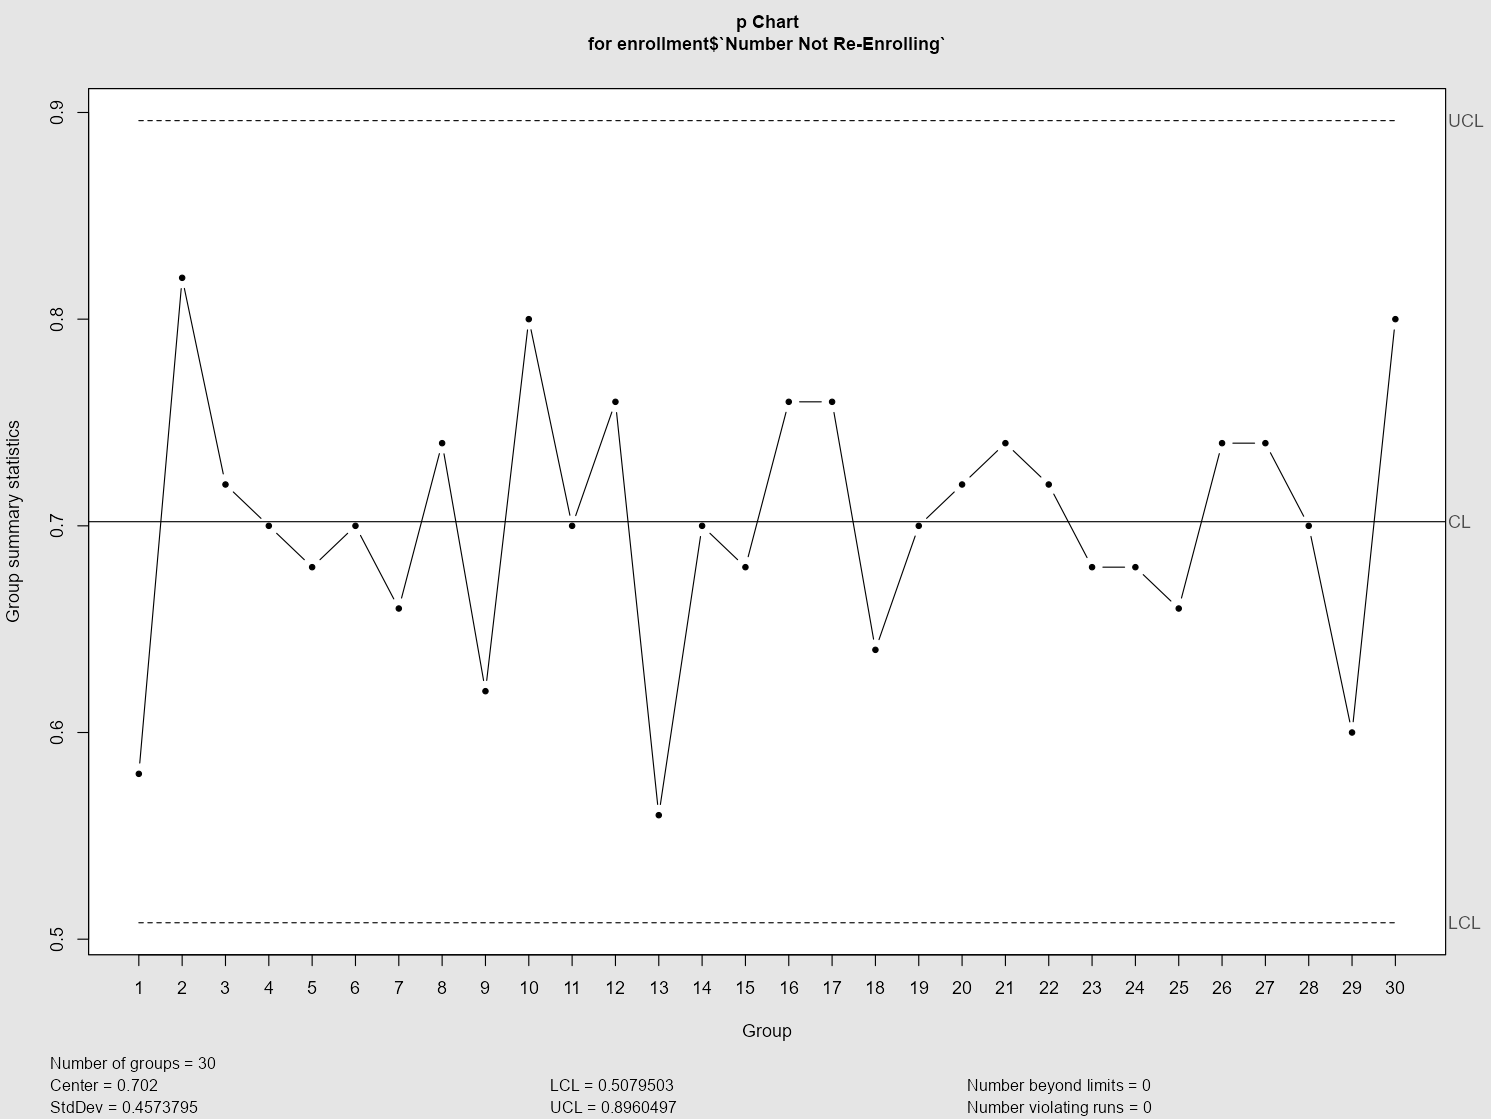

In [4]:
enroll_chart <- qcc(enrollment$`Number Not Re-Enrolling`,
                    type="p",
                    sizes=enrollment$`Sample Size`,
                    plot=TRUE)

## Worked Example: Orange Juice Cans

Now a manufacturing example: we're producing the cardboard cans used to store frozen orange juice, and we visually inspect them for obvious defects that would cause leaking.

We take $m=30$ samples of size $n=50$. The data live in the `Orange Juice Cans.xlsx` spreadsheet (Sheet 1).

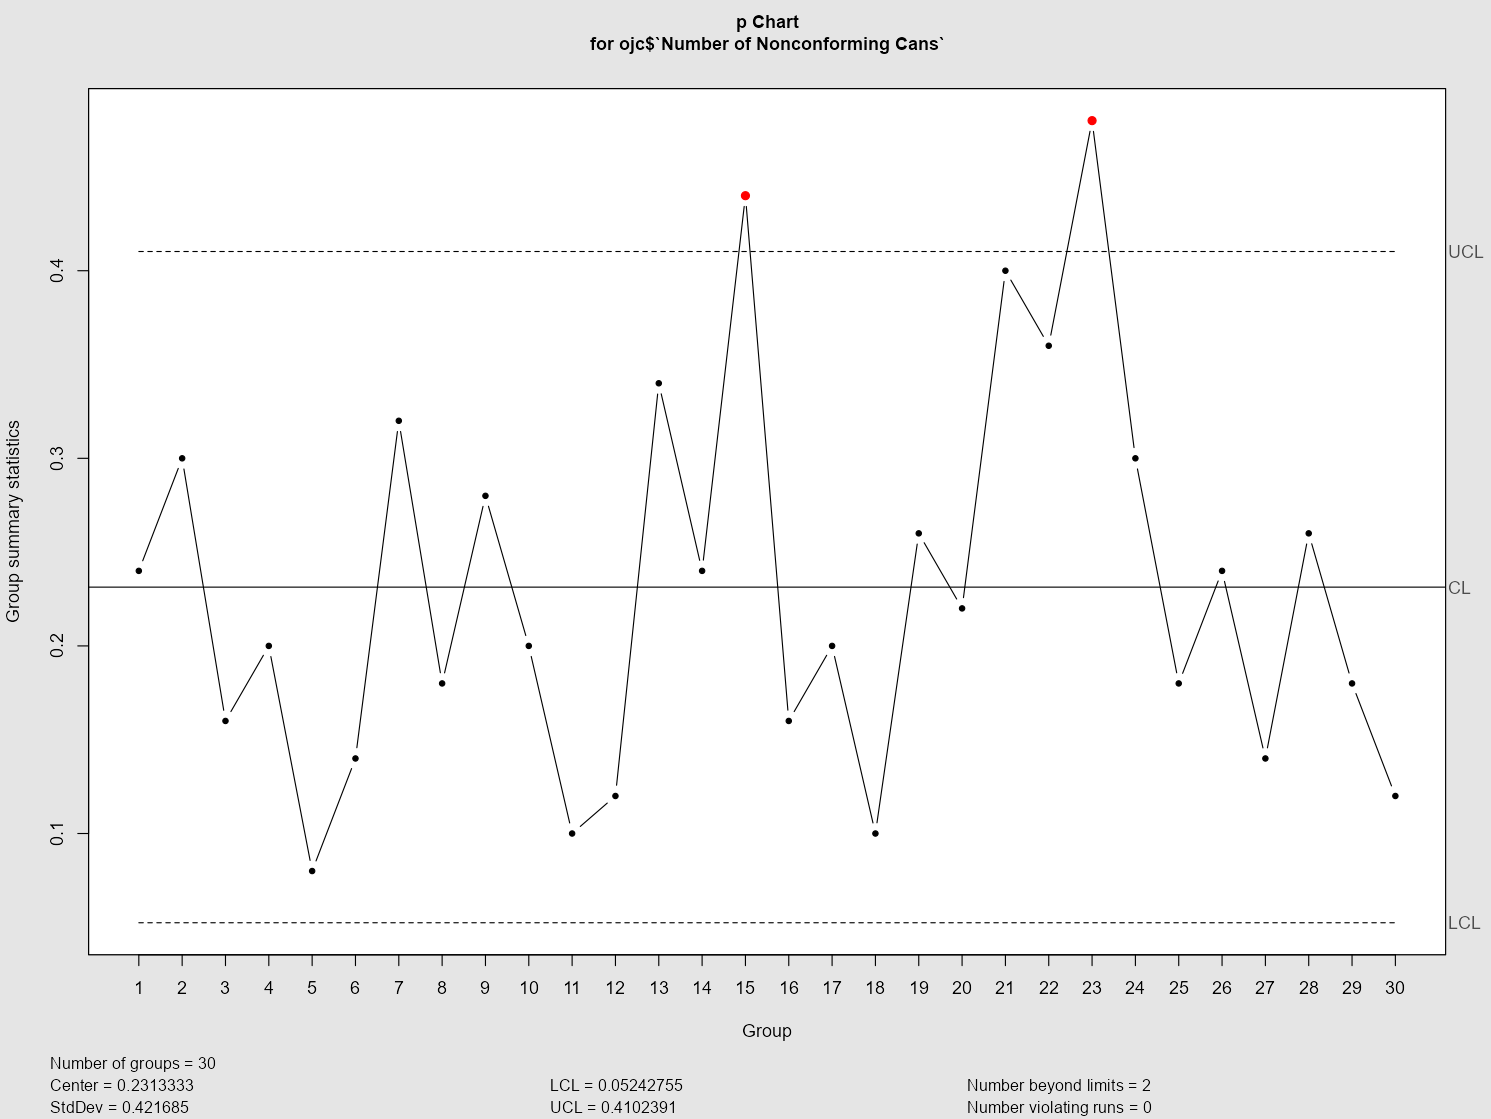

In [5]:
## Phase I Control Chart - Orange Juice Cans ##

ojc <- read_xlsx("Orange Juice Cans.xlsx")

ojc_chart <- qcc(ojc$`Number of Nonconforming Cans`,
                 type="p",
                 sizes=ojc$`Sample Size`,
                 plot=TRUE)

### Cleaning up Phase I: iteratively removing out-of-control points

This is Phase I in action: we have two out-of-control points. As always, the process is to investigate, confirm an assignable cause, then remove the point and recompute the limits. We repeat this process until the chart settles into control. Suppose in this case that the machine applying the adhesive to the cans was almost out of adhesive so not enough was being applied to hold the cans together. The machine was refilled and began operating correctly.

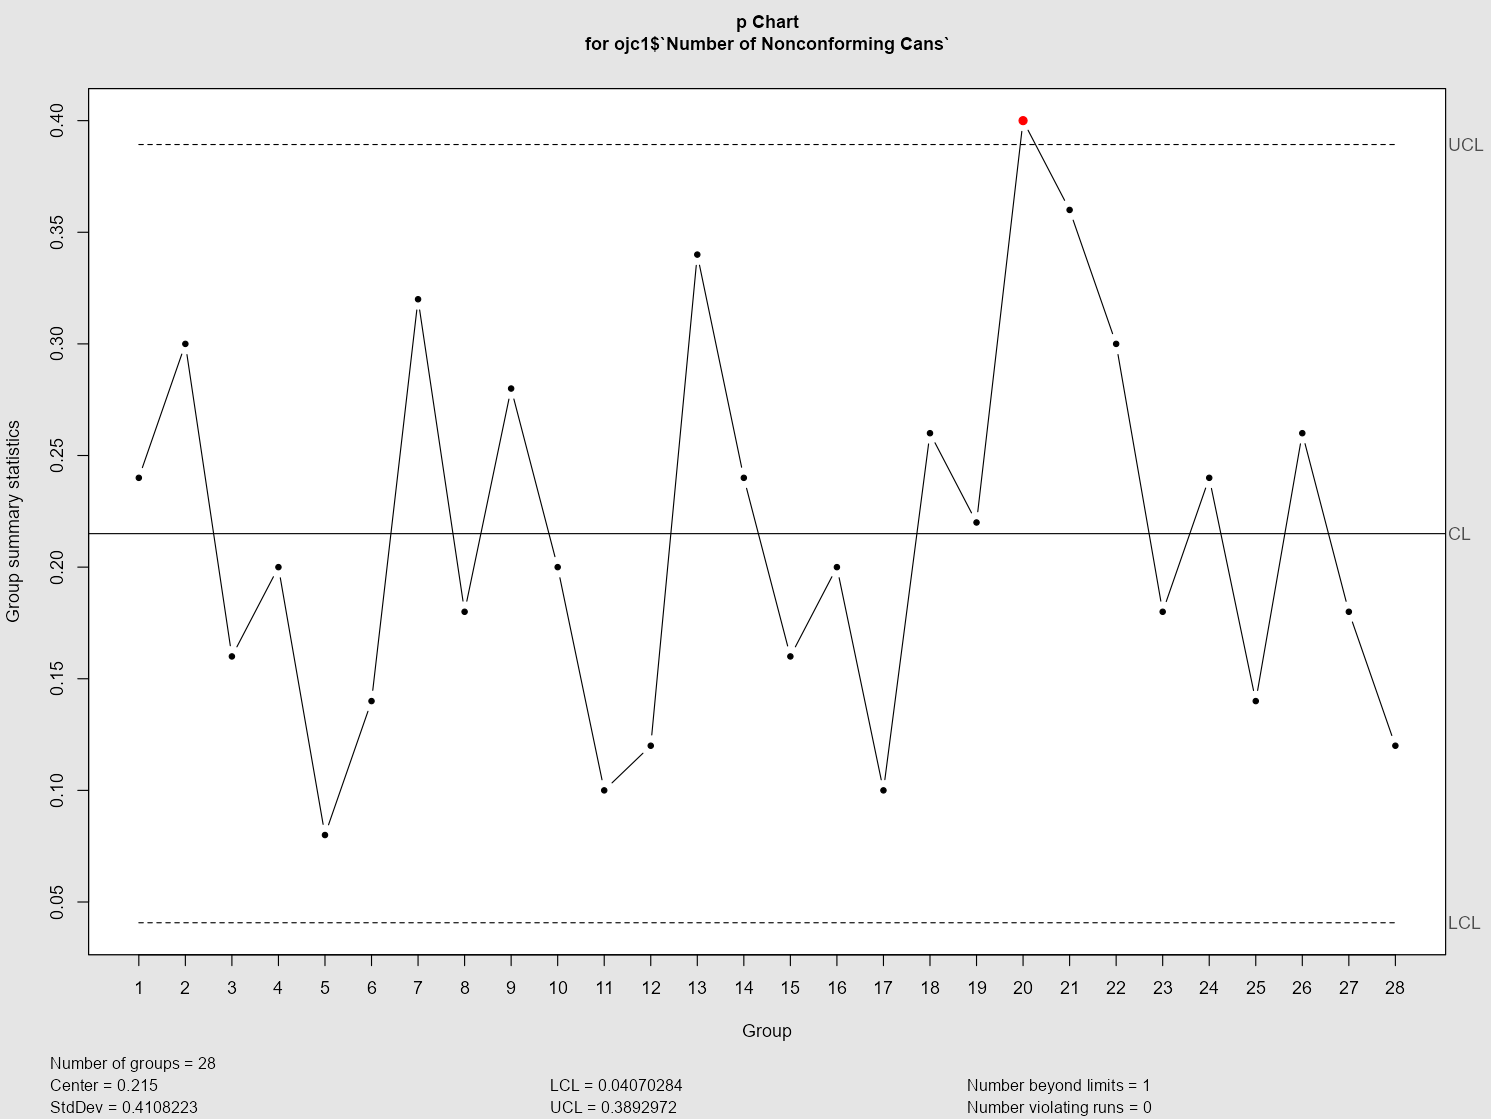

In [6]:
## We have two OOC points -- Let's remove them and recalculate the limits ##

ooc_points <- ojc_chart$violations$beyond.limits

ojc1 <- ojc[-ooc_points,]

ojc_chart1 <- qcc(ojc1$`Number of Nonconforming Cans`,
                  type="p",sizes=ojc1$`Sample Size`,
                  plot=TRUE)

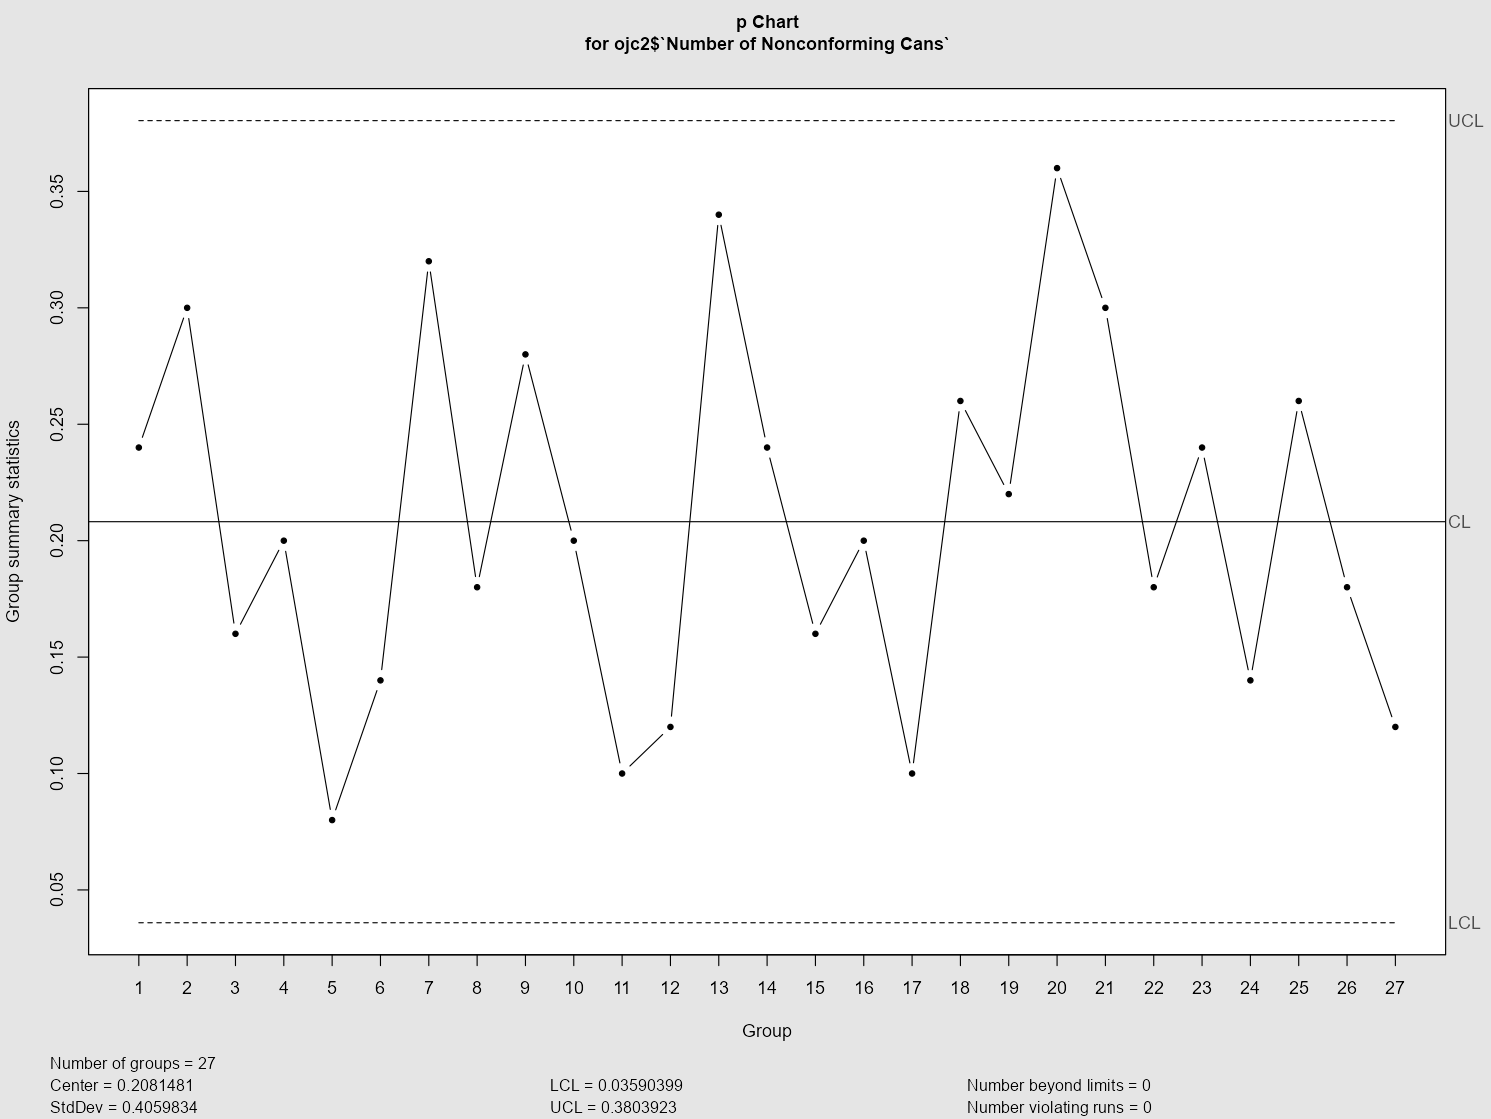

In [7]:
## Now we have another OOC point -- Let's remove it and recalculate ##

ooc_points1 <- ojc_chart1$violations$beyond.limits

ojc2 <- ojc1[-ooc_points1,]

ojc_chart2 <- qcc(ojc2$`Number of Nonconforming Cans`,
                  type="p",sizes=ojc2$`Sample Size`,
                  plot=TRUE)

We identified the cause of the OOC points, confidently omitted them, and now find that the process now plots in control. We're ready to move on to Phase II.

### Phase II: applying the finalized limits to new data

With clean Phase I limits in hand, we can apply them directly to a fresh batch of Phase II data. We can think of this like the training and testing technique we typically apply to supervised learning techniques.

In [8]:
ojcp2 <- read_xlsx("Orange Juice Cans.xlsx",sheet=2)

## Take the Phase I Limits ##

ojc_chart2$limits

uclp <- ojc_chart2$limits[1,2]
lclp <- ojc_chart2$limits[1,1]
pbar <- ojc_chart2$center

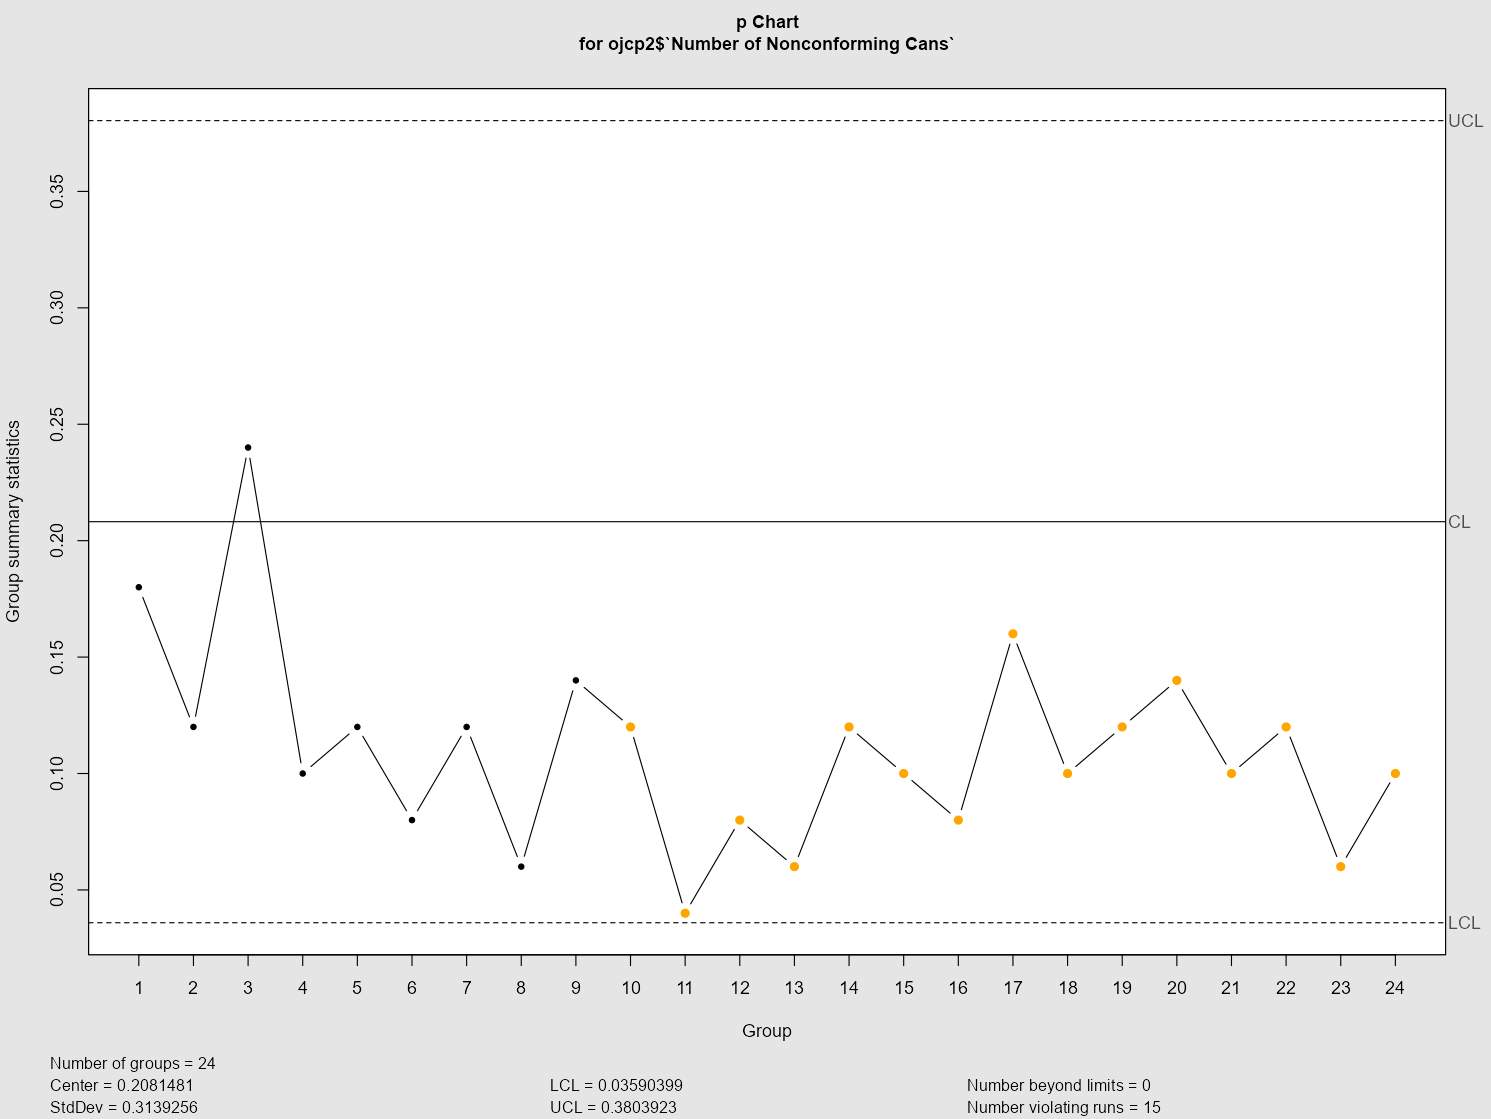

In [9]:
ojc_chartp2 <- qcc(ojcp2$`Number of Nonconforming Cans`,
                   type="p",sizes=ojcp2$`Sample Size`,
                   limits = c(lclp,uclp),
                   center = pbar,
                   plot=TRUE)

Notice that while none of the Phase II points plot out of control, there's still a visible pattern suggesting the proportion nonconforming may have shifted downward. Of course, a lower fraction nonconforming is a good process improvement, but one worth confirming statistically rather than just eyeballing.

### Confirming the shift with a two-sample test

A two-sample proportion test gives us a formal way to check whether the shift we're seeing on the chart is real, or just noise.

In [ ]:
## Let's test it using a two-sample Z test! ##

x1 <- sum(ojc2$`Number of Nonconforming Cans`)
x2 <- sum(ojcp2$`Number of Nonconforming Cans`)
n1 <- sum(ojc2$`Sample Size`)
n2 <- sum(ojcp2$`Sample Size`)

prop.test(c(x1,x2),c(n1,n2),alternative="two.sided",
          correct=FALSE)

Since the $p$-value is quite small, we have significant evidence that the Phase II proportion is genuinely different from our Phase I proportion. The process really has shifted, not just wandered.

## Chart Design: Sample Size & Sampling Interval

Building a $p$ chart in practice means making a few design calls: the sample size $n$, the width of the control limits (typically $L=3\sigma$), and the sampling interval, which is how much time passes between samples.

On the sampling interval: sample at a rate that fits your process. If you're manufacturing Pringles chips, pulling one can per day makes little sense given how fast the line runs. In a lot of modern settings — especially anywhere data is collected automatically — it's entirely reasonable to sample close to 100% of units. The real decision then becomes how to *group* observations into a $\hat{p}$ (hourly, per shift, per batch, etc.), not whether you can afford to sample at all.

### Sample size selection can be more nuanced than it looks

If $p$ (or $\bar{p}$) is small and $n$ is also small, then *any* sample containing even a single nonconforming unit gets flagged as out of control — which usually isn't a reasonable trigger.

For example, suppose $p=0.01$ and $n=8$:

$$ UCL = 0.01 + 3\sqrt{\frac{0.01(0.99)}{8}} = 0.1155 $$
$$ LCL = 0.01 - 3\sqrt{\frac{0.01(0.99)}{8}} = -0.0955 \rightarrow 0 $$

So if a sample turns up just 1 nonconforming unit, $1/8 = 0.125 > UCL$ — the chart signals out of control from a single defect, which is far too trigger-happy to be useful.

### Choosing $n$ to reliably catch at least one nonconformity

To avoid this problem, we want to choose $n$ large enough that we have a high probability of observing at least one nonconformity in a sample:

$$ P[X \geq 1] = \sum_{x=1}^{n}\frac{n!}{x!(n-x)!}(0.01)^x(0.99)^{n-x} $$

Using $P[X \geq 1] = 1 - P[X = 0]$, and since $P[X=0] = (0.99)^n$, if we want $P[X\geq 1] = 0.95$:

$$ 0.95 = 1 - (0.99)^n $$
$$ 0.05 = (0.99)^n $$
$$ \implies n = \frac{\ln(0.05)}{\ln(0.99)} \approx 299 $$

Let's write this as a reusable function rather than redoing the algebra by hand every time.

In [10]:
## Building a Function to Calculate Sample Size for P-Chart ##

pchart_ss <- function(prob,p){
  
  n <- ceiling(log(1-prob)/log(1-p))
  
  return(n)
  
}

pchart_ss(0.95,0.01)

[1] 299

### Choosing $n$ to guarantee a positive LCL

We touched on this earlier — depending on the process, the calculated $LCL$ can come out negative (as it did in the example above, where $LCL = -0.0955$). If we specifically want to be able to detect a **downward** shift, we need $n$ large enough to guarantee a positive $LCL$:

$$ LCL = p - 3\sqrt{\frac{p(1-p)}{n}} > 0 $$
$$ \implies p > 3\sqrt{\frac{p(1-p)}{n}} $$
$$ \implies n > \frac{9(1-p)}{p} $$

Again, let's turn this into a function:

In [11]:
## Function for Sample Size Required to Have a Positive Control Limit ##

nonzero_lcl_ss <- function(p,L){
  
  n <- ceiling(L^2*(1-p)/p)
  
  return(n)
  
}

nonzero_lcl_ss(0.01,3)

[1] 891

## Variable Sample Size $p$ Charts

Just like with the $\bar{x}$ and $R$/$s$ charts, we won't always have equal sample sizes at every time point. This is easy to handle, but it changes our Phase I and Phase II control limit calculations slightly.

We'll still take $m$ samples, but now each has its own sample size $n_i$. Letting $D_i$ be the number of nonconforming units in sample $i$:

$$\bar{p} = \frac{\sum_{i=1}^{m}D_i}{\sum_{i=1}^{m}n_i} $$

And the control limits are nearly identical to before, with the sample size now indexed by $i$ (which makes the limits a "staircase" shape rather than flat lines):

$$ \bar{p} \pm 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n_i}} $$

**Example:** suppose we work in the purchasing department of a company, issuing purchase orders (POs) for supplies every week — a volume that naturally varies week to week. We want to monitor the proportion of POs that contain errors, since PO errors slow down getting supplies and can ripple into other parts of the organization. Our Phase I data live in `POs.xlsx`.

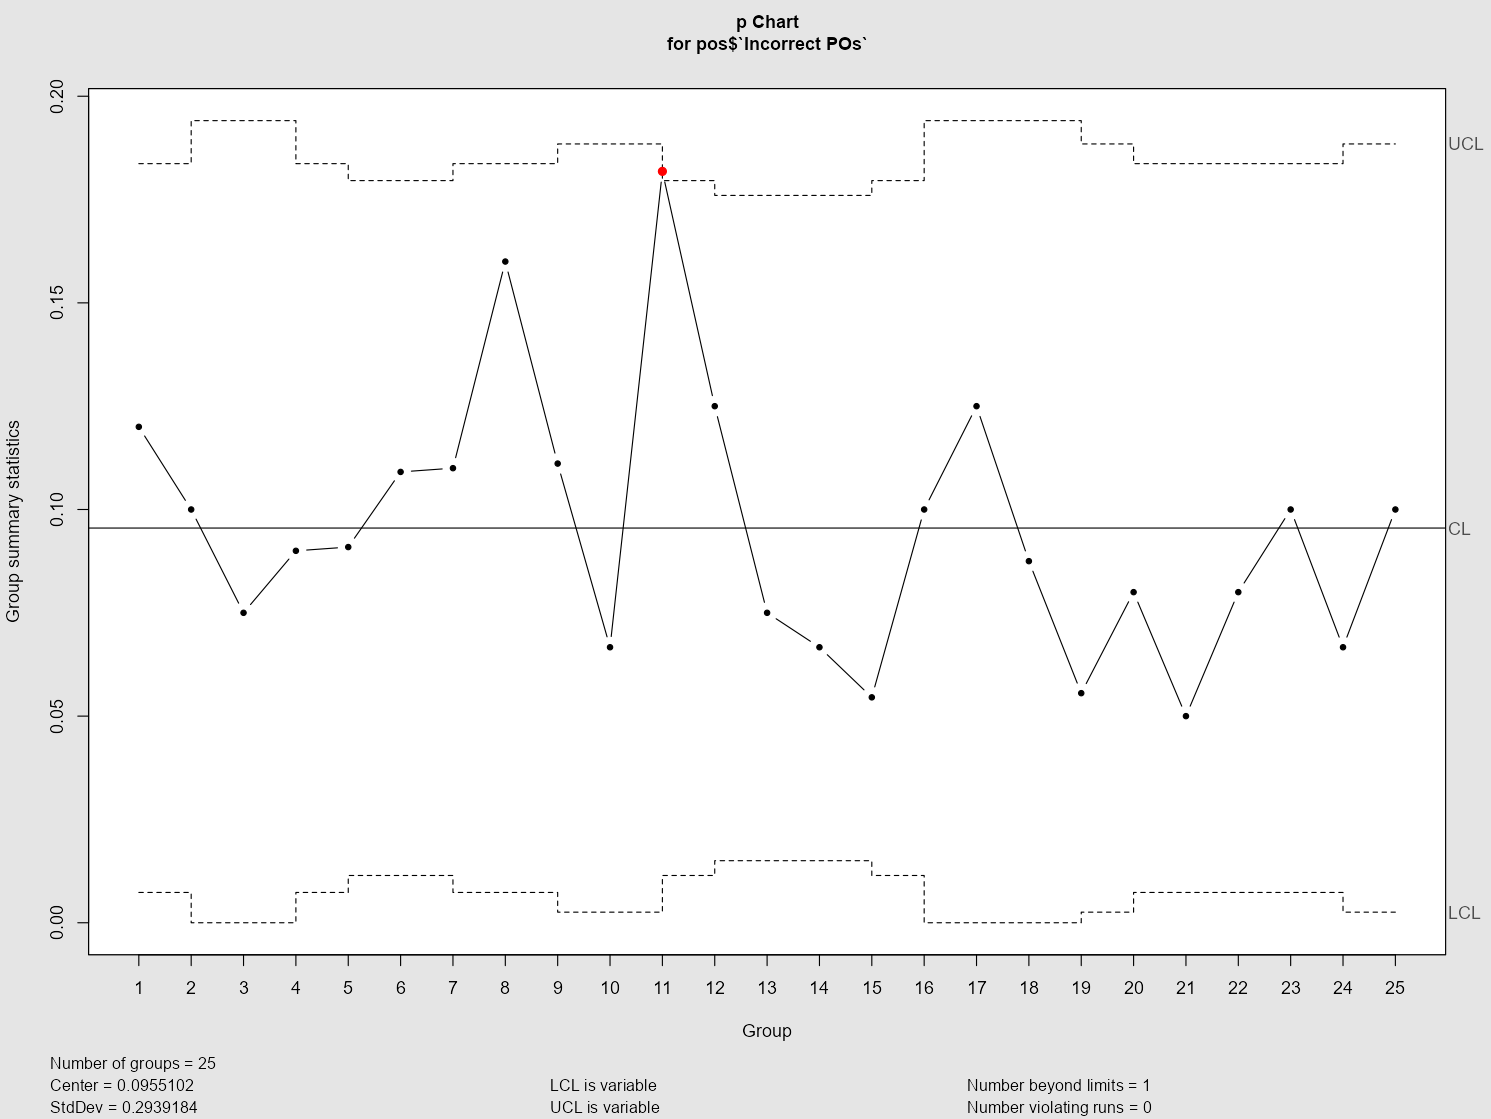

In [12]:
## Read in PO Data ##

pos <- read_xlsx("POs.xlsx")

po_chart <- qcc(pos$`Incorrect POs`,type="p",
                sizes=pos$`Sample Size`,
                plot=T)

### Determining and removing out-of-control points

Let's suppose for our OOC point, somebody who typically doesn't fill out POs happened to fill some out at $t=11$. We can omit this point and recalculate our limits.

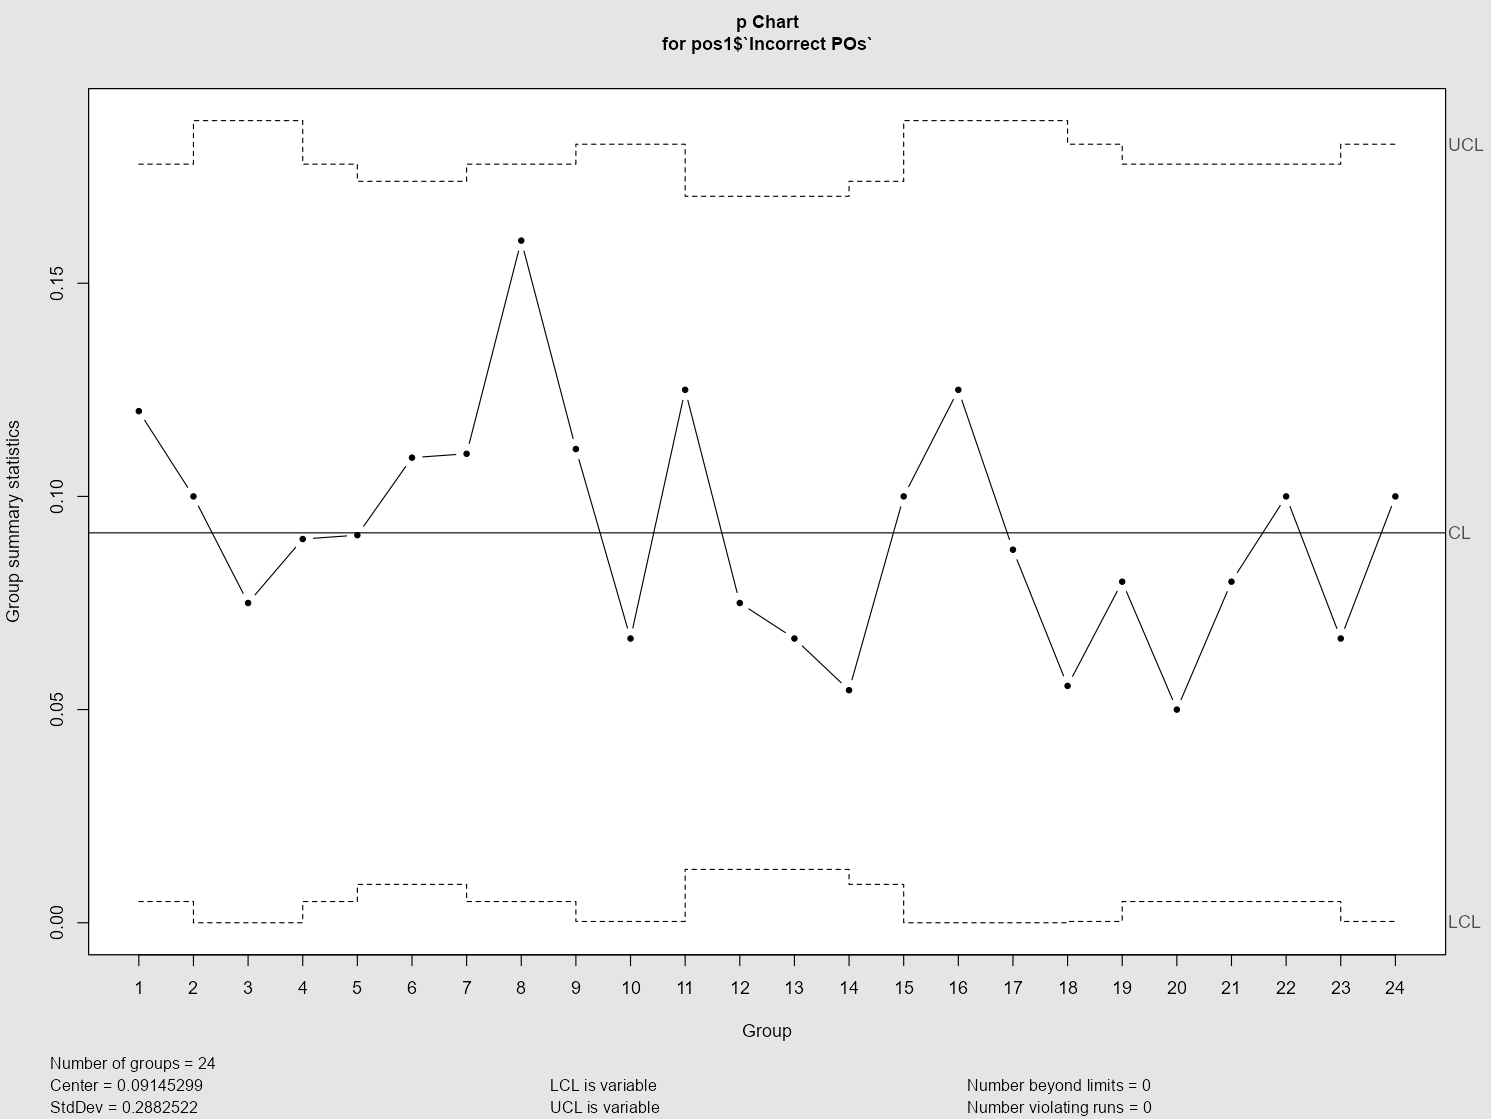

In [13]:
## Determining Out of Control Points ##

ooc_points2 <- po_chart$violations$beyond.limits

## Remove the Points and Re-plot Chart ##

pos1 <- pos[-ooc_points2,]

po_chart1 <- qcc(pos1$`Incorrect POs`,type="p",
                 sizes=pos1$`Sample Size`,
                 plot=T)

## OC Curves & ARL for the $p$ Chart

How do we know, at the design stage, whether our chart will be any good at catching real shifts? Just like for the $\bar{x}$ chart, we can use OC (operating characteristic) curves and average run length (ARL).

Recall the type II error rate, $\beta$, tells us the probability of *failing* to detect a real shift:

$$ \beta = P[LCL < \hat{p} < UCL \,|\, p=p_1] $$
$$ \beta = P[\hat{p} < UCL] - P[\hat{p} \leq LCL] $$
$$ \beta = P[D < nUCL] - P[D \leq nLCL] $$

Since $D$ follows a binomial distribution, we can't get an exact closed-form $\beta$ — we'll rely on the normal approximation instead. Let's use the finalized control limits from the Orange Juice Cans example.

### Calculating $ARL_0$

Since the $p$ chart assumes mutually independent samples, in-control and out-of-control ARLs are calculated exactly as before:

$$ ARL_0 = \frac{1}{\alpha} $$
$$ ARL_1 = \frac{1}{1-\beta} $$

In [14]:
## Calculate ARL0 for the Orange Juice Can Example ##

uclp <- ojc_chart2$limits[1,2]
lclp <- ojc_chart2$limits[1,1]
pbar <- ojc_chart2$center
n <- ojc_chart2$sizes[1]

## First we need to calculate alpha ##

## alpha = P[p > UCL or p < LCL | p = pbar] ##

## alpha = P[p > UCL | p = pbar] + P[p < LCL | p = pbar] ##

## alpha = 1 - P[p < UCL | p = pbar] + P[p < LCL | p = pbar] ##

## So now, since we know phat ~ N(mu = pbar,sigma = sqrt(pbar(1-pbar)/n)), we can use the normal distribution
## to find alpha ##

alpha <- 1 - pnorm(uclp,mean=pbar,sd=sqrt(pbar*(1-pbar)/n)) + pnorm(lclp,pbar,sqrt(pbar*(1-pbar)/n))

In [15]:
## Now we can calculate ARL0 ##

arl0 <- 1/alpha
arl0

[1] 370.3983

### Estimating $\beta$ and $ARL_1$ for a shift from 0.2081 to 0.1108

Now let's see how quickly we'd expect to catch a real shift — say, the fraction nonconforming dropping from 0.2081 to $p_1 = 0.1108$ (a genuine process improvement, like the one we detected statistically earlier).

In [16]:
## Estimate beta for a shift from 0.2081 to p1 = 0.1108 ##

## beta = P[LCL < phat < UCL | p = p1] ##
## beta = P[phat < UCL | p = p1] - P[phat < LCL | p = p1] ##
## This implies that the mean is now p1 and the standard deviation is sqrt(p1(1-p1)/n) ##
## So we can again use pnorm to help us calculate beta ##

p1 <- 0.1108

beta <- pnorm(uclp,p1,sqrt(p1*(1-p1)/n)) - pnorm(lclp,p1,sqrt(p1*(1-p1)/n))
beta

[1] 0.9542203

### Plotting the OC curve

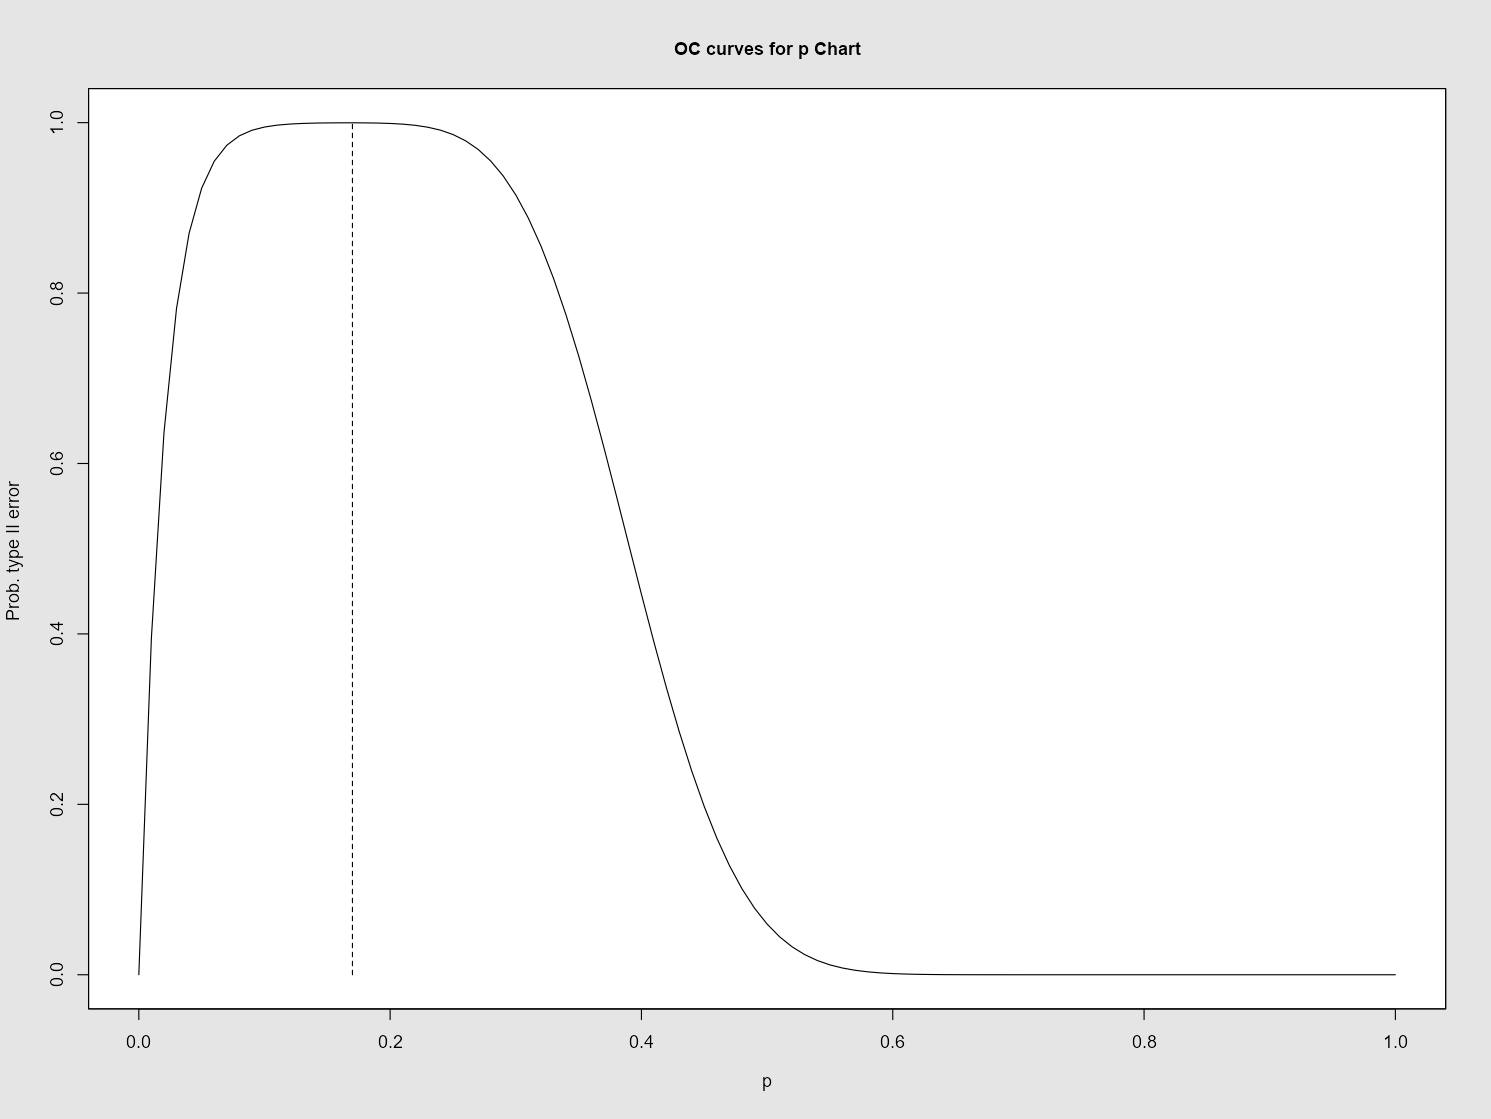

Warning message:
In oc.curves.p(ojc_chart2) :
  Some computed values for the type II error have been rounded due to the discreteness of the binomial distribution. Thus, some ARL values might be meaningless.


In [17]:
## Plotting OC Curve ##

oc.curves.p(ojc_chart2)

In [18]:
## ARL1 ##

arl1 <- 1/(1-beta)

arl1

[1] 21.84377

So it would take roughly **22 samples**, on average, to detect this particular shift. This provides us with a useful context for deciding whether the current sampling plan is fast enough to catch process improvements (or regressions) in a reasonable amount of time.

## Final Remarks

When your quality characteristic is a proportion, the $p$ chart is an effective, well-understood tool. It is particularly good at catching **large** shifts (as is the case with all Shewhart-style charts). But it comes with two real drawbacks worth keeping in mind as you decide whether it's the right chart for the job:

| Limitation | Why it matters |
|---|---|
| Ignores nonconformity **type** and **count** | A unit with 1 minor defect and a unit with 5 severe defects are both just "nonconforming" — the $p$ chart can't distinguish them |
| Fraction nonconforming can be a less intuitive metric | Stakeholders often relate more naturally to a raw *count* of defects than to a proportion, which can slow adoption of the monitoring program |

That second drawback is a natural segue into the next family of attribute charts — the $c$ and $u$ charts — which monitor the **count** of nonconformities directly, rather than collapsing each unit into a simple pass/fail outcome.

## Further Reading on Monitoring Proportions

1. [Bayer, Tondolo, and Muller (2018)](https://arxiv.org/pdf/1804.01454)
2. [Ho, Fernandes, and Bourguignon (2018)](https://onlinelibrary.wiley.com/doi/abs/10.1002/qre.2381?casa_token=FMbcli6AKBoAAAAA%3AM3hn09CGD4R7i-r0bsWBLxwMwxXSeyLSqc_baOg5g_zD7J7Q33B7yUxgWkpdf8sT5IAyPcIzBcBnL9e9)
3. [Joekes and Barbosa (2013)](https://www.sciencedirect.com/science/article/abs/pii/S0967066112002596)

